# 01 — O que são Embeddings?

Embeddings são a base de toda a IA moderna com texto. Este notebook explica:

- O que é um embedding e por que ele existe
- Como o computador "entende" texto como números
- A intuição geométrica: similaridade como proximidade
- Visualizações 2D/3D com PCA e UMAP

---
**Dependências**: `sentence-transformers`, `numpy`, `matplotlib`, `plotly`, `scikit-learn`

## 1.1 O problema: computadores não entendem palavras

Modelos de machine learning trabalham com **números**. Mas texto é... texto.

Como representar:
- `"O gato dorme"` como números?
- De forma que `"O felino repousa"` seja **próximo** a `"O gato dorme"`?
- E `"A bolsa caiu"` seja **distante** de ambos?

Resposta: **Embeddings** — vetores densos aprendidos por modelos de linguagem.

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# Nossas frases de exemplo
frases = [
    "O gato dorme no sofá",           # 0
    "O felino repousa no divã",        # 1 - semanticamente similar a 0
    "Um cachorro late para o carteiro",# 2 - animal, mas diferente
    "A bolsa de valores caiu hoje",    # 3 - completamente diferente
    "Machine learning usa redes neurais",  # 4
    "Deep learning é um tipo de IA",   # 5 - similar a 4
    "Python é uma linguagem de programação",  # 6
    "Receita de bolo de chocolate",    # 7 - totalmente diferente de 4-6
]

# Criar embeddings (cada frase vira um vetor de 384 números)
embeddings = model.encode(frases, normalize_embeddings=True)

print(f"Shape: {embeddings.shape}")
print(f"→ {len(frases)} frases, cada uma representada por {embeddings.shape[1]} números")
print(f"\nPrimeiros 10 valores do embedding da frase 0:")
print(f"  {embeddings[0, :10].round(4)}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Shape: (8, 384)
→ 8 frases, cada uma representada por 384 números

Primeiros 10 valores do embedding da frase 0:
  [-0.0001  0.0165 -0.0327  0.0315 -0.0252 -0.0454  0.0255 -0.0622  0.0261
  0.0833]


## 1.2 Intuição Geométrica

Imagine cada embedding como um **ponto no espaço** (de 384 dimensões).

- Frases com significado similar → **pontos próximos**
- Frases com significado diferente → **pontos distantes**

A **distância** entre pontos mede a **dissimilaridade semântica**.
A **similaridade de cosseno** mede o **ângulo** entre os vetores (0 = idênticos, π/2 = ortogonais).

In [2]:
import pandas as pd

# Calcular matriz de similaridade cosine
# (dot product de vetores normalizados = cosine similarity)
sim_matrix = embeddings @ embeddings.T

labels_curtos = [f[:25] + "..." if len(f) > 25 else f for f in frases]
df_sim = pd.DataFrame(sim_matrix.round(3), index=labels_curtos, columns=labels_curtos)

print("Matriz de Similaridade Cosine (1.0 = idêntico, 0.0 = ortogonal):\n")
print(df_sim.to_string())

print("\n🔍 Observações:")
print(f"  'gato dorme' × 'felino repousa':    {sim_matrix[0,1]:.3f}  ← Alta similaridade!")
print(f"  'gato dorme' × 'bolsa caiu':        {sim_matrix[0,3]:.3f}  ← Baixa similaridade")
print(f"  'machine learning' × 'deep learning': {sim_matrix[4,5]:.3f}  ← Alta similaridade!")
print(f"  'machine learning' × 'bolo de chocolate': {sim_matrix[4,7]:.3f}  ← Baixa")

Matriz de Similaridade Cosine (1.0 = idêntico, 0.0 = ortogonal):

                              O gato dorme no sofá  O felino repousa no divã  Um cachorro late para o c...  A bolsa de valores caiu h...  Machine learning usa rede...  Deep learning é um tipo d...  Python é uma linguagem de...  Receita de bolo de chocol...
O gato dorme no sofá                         1.000                     0.581                         0.416                         0.402                         0.130                         0.250                         0.266                         0.393
O felino repousa no divã                     0.581                     1.000                         0.489                         0.464                         0.088                         0.225                         0.196                         0.414
Um cachorro late para o c...                 0.416                     0.489                         1.000                         0.439                         0.

## 1.3 Visualização 2D com PCA

384 dimensões não dá pra visualizar diretamente.
Usamos **PCA** para reduzir para 2D mantendo a maior variância.

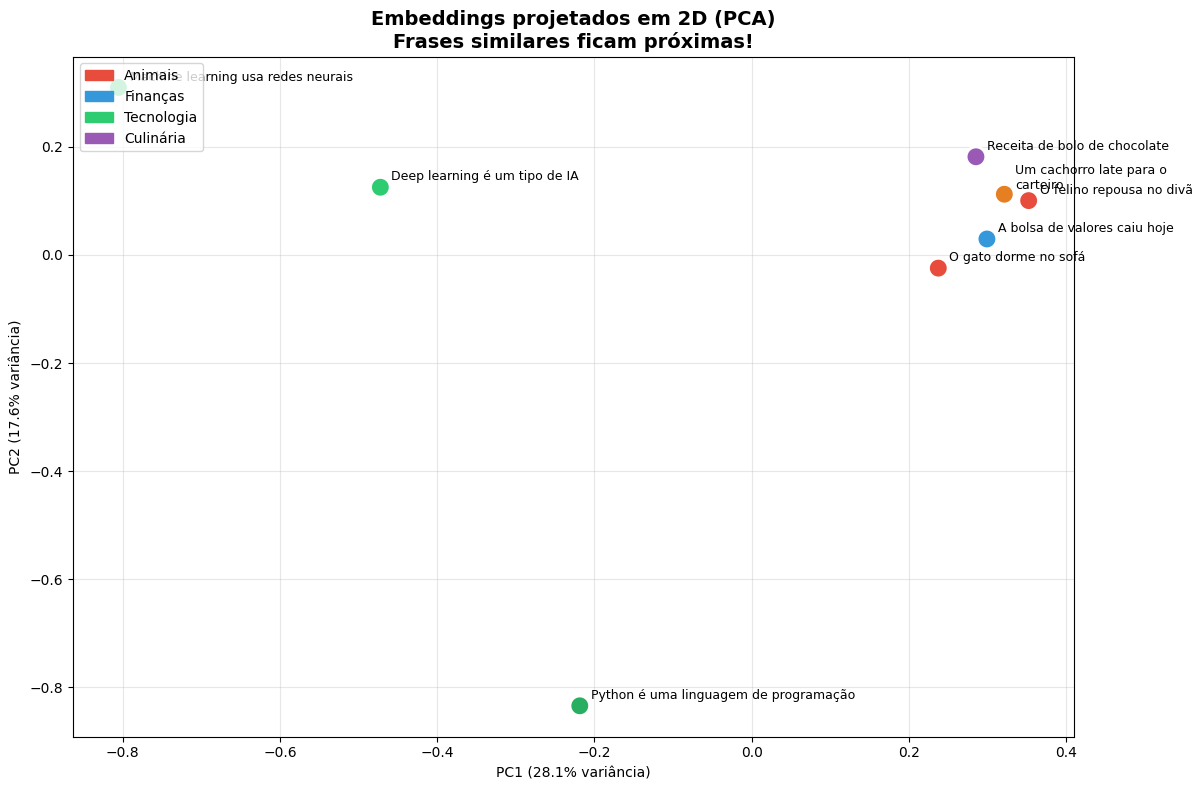

💡 Observe como frases da mesma categoria ficam agrupadas!


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Cores por categoria
cores = ["#e74c3c", "#e74c3c",  # animais (vermelho)
         "#e67e22",              # animal diferente
         "#3498db",             # finanças (azul)
         "#2ecc71", "#2ecc71", "#27ae60",  # tecnologia (verde)
         "#9b59b6"]             # culinária (roxo)

categorias = ["Animais", "Animais", "Animais", "Finanças",
              "Tecnologia", "Tecnologia", "Tecnologia", "Culinária"]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
           c=cores, s=200, zorder=3, edgecolors='white', linewidths=2)

for i, (x, y) in enumerate(embeddings_2d):
    ax.annotate(
        frases[i],
        (x, y),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
        wrap=True,
    )

patches = [
    mpatches.Patch(color='#e74c3c', label='Animais'),
    mpatches.Patch(color='#3498db', label='Finanças'),
    mpatches.Patch(color='#2ecc71', label='Tecnologia'),
    mpatches.Patch(color='#9b59b6', label='Culinária'),
]
ax.legend(handles=patches, loc='upper left', fontsize=10)

ax.set_title("Embeddings projetados em 2D (PCA)\nFrases similares ficam próximas!", 
             fontsize=14, fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 Observe como frases da mesma categoria ficam agrupadas!")

## 1.4 Visualização 3D interativa com Plotly

In [4]:
import plotly.express as px
from sklearn.decomposition import PCA

pca3 = PCA(n_components=3)
emb_3d = pca3.fit_transform(embeddings)

df_3d = pd.DataFrame({
    "PC1": emb_3d[:, 0],
    "PC2": emb_3d[:, 1],
    "PC3": emb_3d[:, 2],
    "texto": frases,
    "categoria": categorias,
})

fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='categoria',
    text='texto',
    title='Embeddings em 3D (PCA) — Rotacione para ver os clusters!',
    width=900, height=600,
)

fig.update_traces(textposition='top center', textfont_size=9, marker_size=8)
fig.show()

## 1.5 Analogias Vetoriais: Álgebra de Significado

Uma propriedade fascinante dos embeddings:

> **rei - homem + mulher ≈ rainha**

Podemos fazer **aritmética com significados**!

In [5]:
words = ["rei", "rainha", "homem", "mulher", "Paris", "França", "Berlim", "Alemanha",
         "Python", "programação", "Java", "computador"]

word_embeddings = model.encode(words, normalize_embeddings=True)
word_dict = {w: emb for w, emb in zip(words, word_embeddings)}

def analogia(a, b, c, vocab=word_dict, top_k=3):
    """a - b + c = ?"""
    resultado = word_dict[a] - word_dict[b] + word_dict[c]
    resultado = resultado / np.linalg.norm(resultado)
    
    candidatos = [(w, float(resultado @ emb)) 
                  for w, emb in word_dict.items() 
                  if w not in (a, b, c)]
    candidatos.sort(key=lambda x: -x[1])
    
    return candidatos[:top_k]

print("Analogias vetoriais com embeddings:\n")
print(f"rei - homem + mulher = ?")
print(f"  Top: {analogia('rei', 'homem', 'mulher')}")

print(f"\nParis - França + Alemanha = ?")
print(f"  Top: {analogia('Paris', 'França', 'Alemanha')}")

print(f"\nPython - programação + computador = ?")
print(f"  Top: {analogia('Python', 'programação', 'computador')}")

print("\n💡 Nota: com vocabulário pequeno, os resultados são limitados.")
print("   Com modelos maiores e vocabulário maior, as analogias ficam muito mais precisas!")

Analogias vetoriais com embeddings:

rei - homem + mulher = ?
  Top: [('rainha', 0.1934199333190918), ('Paris', 0.18708977103233337), ('Alemanha', 0.16799597442150116)]

Paris - França + Alemanha = ?
  Top: [('rainha', 0.3907516598701477), ('mulher', 0.24835404753684998), ('rei', 0.2060714066028595)]

Python - programação + computador = ?
  Top: [('Berlim', 0.2719472050666809), ('mulher', 0.24174754321575165), ('Java', 0.23640254139900208)]

💡 Nota: com vocabulário pequeno, os resultados são limitados.
   Com modelos maiores e vocabulário maior, as analogias ficam muito mais precisas!


## 1.6 Como os Embeddings são criados?

O modelo `all-MiniLM-L6-v2` usa uma arquitetura **BERT-like**:

```
Texto → Tokenização → Transformer (6 camadas) → [CLS] token → Projeção → Vetor 384d
```

O modelo foi **treinado com contrastive learning**:
- Pares similares → vetores próximos
- Pares dissimilares → vetores distantes

Dataset de treino: ~1 bilhão de pares de frases semânticas.

In [6]:
# Ver informações do modelo
print(f"Modelo: {model._model_card_text[:200] if hasattr(model, '_model_card_text') else 'all-MiniLM-L6-v2'}")
print(f"\nDimensões de saída: {model.get_sentence_embedding_dimension()}")
print(f"Máximo de tokens: {model.max_seq_length}")

# Ver quantos parâmetros o modelo tem
total_params = sum(p.numel() for p in model.parameters())
print(f"Parâmetros: {total_params:,} (~{total_params/1e6:.0f}M)")

Modelo: ---
language: en
license: apache-2.0
library_name: sentence-transformers
tags:
- sentence-transformers
- feature-extraction
- sentence-similarity
- transformers
datasets:
- s2orc
- flax-sentence-embed

Dimensões de saída: 384
Máximo de tokens: 256
Parâmetros: 22,713,216 (~23M)


C:\Users\USER\AppData\Local\Temp\claude\ipykernel_6228\32583081.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"\nDimensões de saída: {model.get_sentence_embedding_dimension()}")


## Resumo

| Conceito | O que aprendemos |
|---------|------------------|
| Embedding | Vetor de números que representa o significado de um texto |
| Dimensão | Tamanho do vetor (MiniLM = 384, MPNet = 768) |
| Similaridade cosine | Mede o ângulo entre dois vetores (0 = idênticos) |
| PCA/UMAP | Reduz dimensionalidade para visualização |
| Analogias | Podemos fazer aritmética com significados! |

## Próximos passos

- [02 — Vector Dimensions](02_vector_dimensions.ipynb): Por que 384 vs 768 vs 1024?
- [03 — Float Types](03_float_types.ipynb): Como comprimir embeddings sem perder qualidade?
- [04 — Distance Metrics](04_distance_metrics.ipynb): Quando usar cosine vs euclidean?